In [37]:
import pandas as pd
import numpy as np
df=pd.read_csv("diabetes.csv")
df

from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import precision_score
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.model_selection import train_test_split
from sklearn import metrics
import numpy as np
from sklearn.ensemble import RandomForestClassifier

In [16]:
x=df.drop('Outcome',axis=1)
y=df['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
RF=RandomForestClassifier(criterion='entropy',random_state=42,n_estimators=51)
RF.fit(x_train,y_train)
y_pred=RF.predict(x_test)
print(accuracy_score(y_test,y_pred))
print(classification_report(y_test,y_pred))

0.7662337662337663
              precision    recall  f1-score   support

           0       0.82      0.82      0.82        99
           1       0.67      0.67      0.67        55

    accuracy                           0.77       154
   macro avg       0.75      0.75      0.75       154
weighted avg       0.77      0.77      0.77       154



In [17]:
df=pd.read_csv("titanic.csv")
df

,pclass,name,sex,age,sibsp,parch,ticket,fare,cabin,embarked,survived
0,1,"Allen, Miss. Elisabeth Walton",female,29.0000,0,0,24160,211.3375,B5,S,1
1,1,"Allison, Master. Hudson Trevor",male,0.9167,1,2,113781,151.5500,C22 C26,S,1
2,1,"Allison, Miss. Helen Loraine",female,2.0000,1,2,113781,151.5500,C22 C26,S,0
3,1,"Allison, Mr. Hudson Joshua Creighton",male,30.0000,1,2,113781,151.5500,C22 C26,S,0
4,1,"Allison, Mrs. Hudson J C (Bessie Waldo Daniels)",female,25.0000,1,2,113781,151.5500,C22 C26,S,0
...,...,...,...,...,...,...,...,...,...,...,...
1304,3,"Zabour, Miss. Hileni",female,14.5000,1,0,2665,14.4542,NaN,C,0
1305,3,"Zabour, Miss. Thamine",female,NaN,1,0,2665,14.4542,NaN,C,0
1306,3,"Zakarian, Mr. Mapriededer",male,26.5000,0,0,2656,7.2250,NaN,C,0
1307,3,"Zakarian, Mr. Ortin",male,27.0000,0,0,2670,7.2250,NaN,C,0


In [18]:
df.isna().sum()

pclass         0
name           0
sex            0
age          263
sibsp          0
parch          0
ticket         0
fare           1
cabin       1014
embarked       2
survived       0
dtype: int64

In [19]:
df.embarked=df.embarked.fillna(df.embarked.mode()[0])


In [20]:
df=df.fillna(df.mean(numeric_only=True))

In [32]:

y=df['survived']
x=df.drop('survived',axis=1)
x=pd.get_dummies(x)
x

,pclass,age,sibsp,parch,fare,"name_Abbing, Mr. Anthony","name_Abbott, Master. Eugene Joseph","name_Abbott, Mr. Rossmore Edward","name_Abbott, Mrs. Stanton (Rosa Hunt)","name_Abelseth, Miss. Karen Marie",...,cabin_F G73,cabin_F2,cabin_F33,cabin_F38,cabin_F4,cabin_G6,cabin_T,embarked_C,embarked_Q,embarked_S
0,1,29.000000,0,0,211.3375,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
1,1,0.916700,1,2,151.5500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
2,1,2.000000,1,2,151.5500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
3,1,30.000000,1,2,151.5500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
4,1,25.000000,1,2,151.5500,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1304,3,14.500000,1,0,14.4542,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1305,3,29.881135,1,0,14.4542,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1306,3,26.500000,0,0,7.2250,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False
1307,3,27.000000,0,0,7.2250,False,False,False,False,False,...,False,False,False,False,False,False,False,True,False,False


In [27]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score


In [29]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
ac_knn=0
for i in range(27,45):
    knn=KNeighborsClassifier(n_neighbors=i)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac=accuracy_score(y_test,y_pred)
    if ac>ac_knn:
        ac_knn=ac
        neighbor=i
print(ac,">",neighbor)
plt.plot(


0.6526717557251909 > 37


In [34]:
from sklearn.tree import DecisionTreeClassifier

In [35]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
ac_dt=0
for i in range(1,50):
    DT=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=i)
    DT.fit(x_train,y_train)
    y_pred=DT.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_dt:
        ac_dt=ac
        depth=i
print(ac_dt,">",i)
        
    

    

0.8091603053435115 > 49


In [39]:
from sklearn.ensemble import RandomForestClassifier

In [40]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
ac_rf=0
for i in range(30,100):
    rf=RandomForestClassifier(n_estimators=i,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac=accuracy_score(y_pred,y_test)
    if ac>ac_rf:
        ac_rf=ac
        depth=i
print(ac_rf,">",i)

0.7824427480916031 > 99


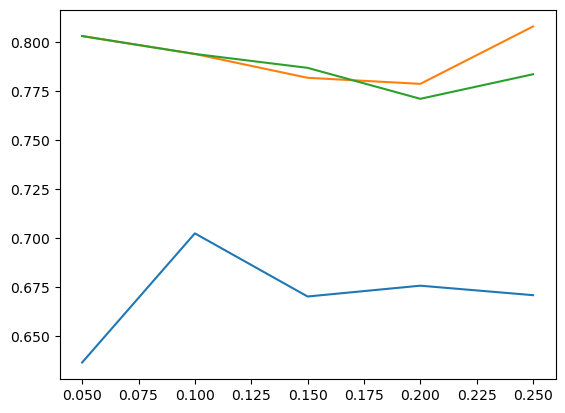

In [47]:
ac_knn=[]
ac_dt=[]
ac_rf=[]
test=[0.05,0.1,0.15,0.2,0.25]
for i in test:
    x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=i, random_state=42)
    knn=KNeighborsClassifier(n_neighbors=39)
    knn.fit(x_train,y_train)
    y_pred=knn.predict(x_test)
    ac_knn.append(accuracy_score(y_test,y_pred))
    DT=DecisionTreeClassifier(criterion='entropy',random_state=42,max_depth=3)
    DT.fit(x_train,y_train)
    y_pred=DT.predict(x_test)
    ac_dt.append(accuracy_score(y_test,y_pred))
    rf=RandomForestClassifier(n_estimators=45,criterion='entropy',random_state=42)
    rf.fit(x_train,y_train)
    y_pred=rf.predict(x_test)
    ac_rf.append(accuracy_score(y_test,y_pred))
plt.plot(test,ac_knn)
plt.plot(test,ac_dt)
plt.plot(test,ac_rf)


    
    
    
    
    